In [136]:
import matplotlib.pyplot as plt
import matplotlib
import numpy
import os
import gc

from rascil.processing_components import plot_uvcoverage

from radioimaging.visibility import ingest, bda, residual
from radioimaging import images
from radioimaging.util import util

from statsmodels.distributions.empirical_distribution import ECDF
from scipy.interpolate import interp1d
from radioimaging.visibility import partition

from ska_sdp_func_python.imaging import advise_wide_field
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

plt.set_loglevel("critical")
cmap='turbo'
matplotlib.rcParams['figure.figsize'] = [5, 5]
from rascil.processing_components import create_visibility_from_ms

In [137]:
dataset_name = "/home/sunwang/radio-imaging/data8/MID/SGRA_full_averaged.ms/"
output_name = "/home/sunwang/radio-imaging/data8/test3_"
num_channels = 1

[vis], _ = ingest.create_visibility_from_ms(dataset_name, use_weight_spec=True, start_chan=0, end_chan=0, selected_dds=[0])
npix = 512
scale_factor = 1.8
advice = advise_wide_field(vis, guard_band_image=3.0, delA=0.1, facets=1, oversampling_synthesised_beam=4.0)
cell_size = advice['cellsize'] * scale_factor
print(cell_size)

8.755168963737264e-07


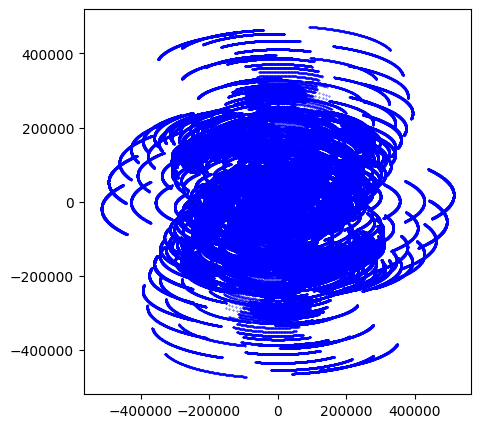

In [138]:
u = numpy.array(vis.visibility_acc.uvw_lambda[..., 0].values.flatten())
v = numpy.array(vis.visibility_acc.uvw_lambda[..., 1].values.flatten())
plt.scatter(u, v, s=0.1, c='b')
plt.scatter(-u, -v, s=0.1, c='b')
plt.savefig("../figures/uv.png", pad_inches=0.0, bbox_inches='tight')

Model image plate scale (arcsec) is 1.805883e-01


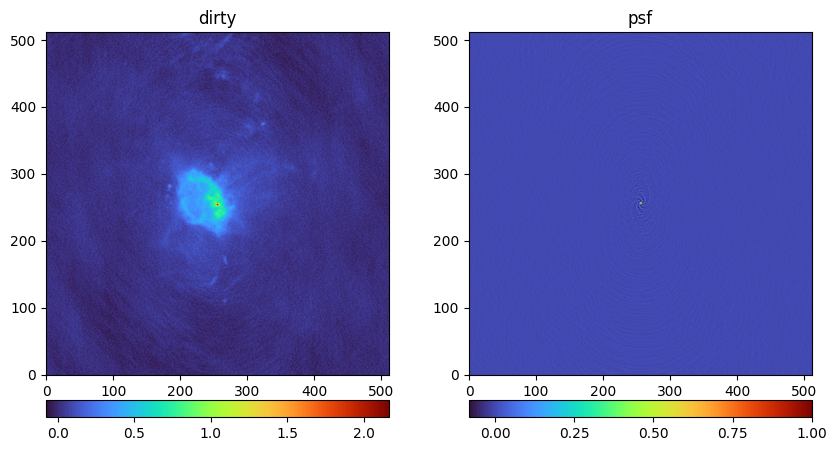

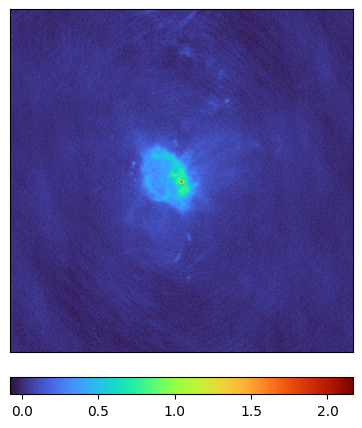

In [139]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

dirty, psf = residual.dirty_psf_from_visibilities(vis,cell_size,npix=npix,weighting="uniform", override_cellsize=False)
fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(dirty.pixels.data[0,0,:,:]))))
fpsf = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(psf.pixels.data[0,0,:,:]))))

util.plotNImages([dirty.pixels.data[0,0,:,:], psf.pixels.data[0,0,:,:]], ["dirty", "psf"], cmap=cmap)
util.plotNImages([dirty.pixels.data[0, 0,:,:]], [""], cmap=cmap, output_file="../figures/lowdirty.pdf", hide_ticks=True)

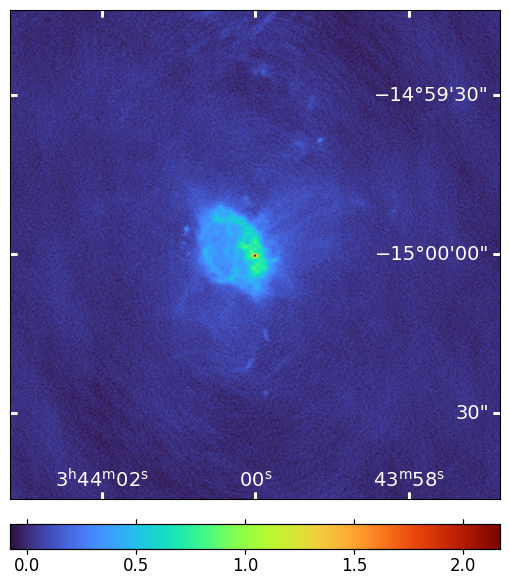

In [142]:
from mpl_toolkits.axes_grid1 import make_axes_locatable
from matplotlib.ticker import MaxNLocator
import matplotlib.transforms as mtransforms
import astropy.units as u
fig = plt.figure(figsize=(7,7))
ax=fig.add_subplot(1,1,1,projection=dirty.image_acc.wcs.sub([1, 2]))
im = ax.imshow(dirty.pixels.data[0,0,:,:],origin='lower',cmap=cmap)

ax.coords[0].set_ticks(number=4 * u.one)
ax.coords[1].set_ticks(number=3 * u.one) 

divider = make_axes_locatable(ax)
cax = divider.append_axes("bottom", size="5%", pad=0.25)
cb = fig.colorbar(im, orientation='horizontal', cax=cax)
cb.ax.locator_params(nbins=5)
cb.ax.tick_params(axis='y', which='right', left=False, right=False, labelright=False)
cb.ax.tick_params(labelsize=12)


ax.tick_params(
    axis='x', 
    which='major', 
    direction='in',
    colors='white',
    width=2,
    length=5,
    labelsize=14,
    pad=-20,
)

ax.tick_params(
    axis='y', 
    which='major', 
    direction='in',
    colors='white',
    width=2,
    length=5,
    labelsize=14,
    pad=-345
)

ax.set_xlabel("", fontsize=14)
ax.set_ylabel("", fontsize=14)
plt.savefig("../figures/middirty.pdf", pad_inches=0.0, bbox_inches='tight')

In [109]:
ells = [30]
use_hardcoded_ells = False
delta = 1
partitions=6

uvlambdas = numpy.array(vis.visibility_acc.uvw_lambda[..., 0, 0:2])
uvlambdas = uvlambdas.reshape((int(uvlambdas.shape[0] * uvlambdas.shape[1]), 2))
dist = numpy.zeros(uvlambdas.shape[0])
for i, uvlambda in enumerate(uvlambdas):
    dist[i] = numpy.sqrt(uvlambda[0]**2 + uvlambda[1]**2)  * cell_size * npix

ecdf = ECDF(dist)
cdf = interp1d(ecdf.x, ecdf.y, bounds_error=False, assume_sorted=True)
icdf = interp1d(ecdf.y, ecdf.x, bounds_error=False, assume_sorted=True)

if not use_hardcoded_ells:
    alpha = partition.dichotomy(cdf, icdf, delta, partitions, tolerance=1e-15)
    ells, partition_sizes = partition.get_partitions(cdf, icdf, delta, partitions, alpha)
    
    ells_rounded = [round(x, 2) for x in ells]
    partition_sizes_rounded = partition.get_bin_sizes(cdf, ells_rounded, delta)
else:
    ells_rounded = ells
    partition_sizes_rounded = partition.get_bin_sizes(cdf, ells_rounded, delta)

print(ells_rounded)
print(partition_sizes_rounded)

#vis = None
gc.collect()

[35.04, 55.67, 73.69, 94.28, 130.09]
[0.19111900475806257, 0.19118526575332262, 0.19103863358906653, 0.19110191675668414, 0.19125091489443147, 0.191111619368733]


246179

In [6]:
partition_colours = ["red", "magenta", "blue", "magenta"]
total_regions = 2 * partitions - 1
regions = []

for i, ell in enumerate(ells_rounded):
    before = ells_rounded[i - 1] + delta if i > 0 else 0

    regions.append((before, ell - delta))
    regions.append((ell - delta, ell + delta))

    if i == len(ells_rounded) - 1:
        regions.append((ell + delta, npix))

partition_colours = ["salmon", "mediumpurple", "cornflowerblue", "mediumpurple"]

region_colours = []
idx = 0
for region in regions:
    region_colours.append(partition_colours[idx])
    idx = (idx + 1) % len(partition_colours)

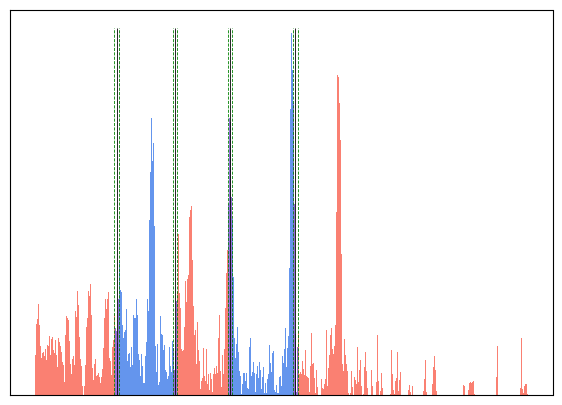

In [7]:
matplotlib.rcParams['figure.figsize'] = [7, 5]

def find_region_idx(x, regions):
    for i, region in enumerate(regions):
        if x >= region[0] and x < region[1]:
            return i

    return -1

show_inset = False
inset_min = 0
inset_max = 10

transit_lines = []
for ell in ells_rounded:
    transit_lines.append(ell - delta)
    transit_lines.append(ell + delta)

fig, ax = plt.subplots()

n, bins, patches = ax.hist(dist, bins=npix*10, density=True)

for patch in patches:
    idx = find_region_idx(patch.get_x(), regions)
    patch.set_facecolor(region_colours[idx])

ymin = 0
ymax = numpy.max(n)

ax.vlines(ells, ymin, ymax, colors='black', linewidth=0.6)
ax.vlines(transit_lines, ymin, ymax, colors='g', linestyles='dashed', linewidth=0.6)

ax.set_xticks([])
ax.set_yticks([])

if show_inset:
    axins = inset_axes(ax, width="60%", height="60%", loc='upper right')
    _, _, inpatches = axins.hist(dist, bins=npix*10, density=True)
    for patch in inpatches:
        idx = find_region_idx(patch.get_x(), regions)
        patch.set_facecolor(region_colours[idx])
        
    axins.vlines(ells, ymin, ymax, colors='black', linewidth=0.6)
    axins.vlines(transit_lines, ymin, ymax, colors='g', linestyles='dashed', linewidth=0.6)
    axins.set_xlim(inset_min, inset_max)
    axins.set_ylim(0, ymax)
    mark_inset(ax, axins, loc1=2, loc2=4, fc="None", ec='slategrey', lw=1)
    
    axins.set_xticks([])
    axins.set_yticks([])
    
    axins.patch.set_linewidth(1)
    axins.patch.set_edgecolor('slategrey')

    for spine in axins.spines.values():
        spine.set_edgecolor('slategrey')
        spine.set_linewidth(1)   

plt.savefig("../figures/partition_mid_bda99.png", pad_inches=0.0, bbox_inches='tight')

In [8]:
centers_str = ""
for ell in ells:
    centers_str += str(ell) + " "
    
split_exec = "python split_datasets.py --idataset_name " + dataset_name + " --num_pix " + str(npix) + \
    " --pix_rad " + str(cell_size) + " --halfwidth " + str(delta) + " --centers " + centers_str + \
    "--odataset_name " + output_name

os.system(split_exec)

2025-12-04 11:05:48	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-12-04 11:05:55	INFO	SubMS::makeSelection()	809317 out of 3685120 rows are going to be considered due to the selection criteria.
2025-12-04 11:05:59	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-12-04 11:06:05	INFO	SubMS::makeSelection()	809312 out of 3685120 rows are going to be considered due to the selection criteria.
2025-12-04 11:06:09	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-12-04 11:06:14	INFO	SubMS::makeSelection()	809217 out of 3685120 rows are going to be considered due to the selection criteria.
2025-12-04 11:06:18	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-12-04 11:06:23	INFO	SubMS::makeSelection()	809417 out of 3685120 rows are going to be considered due to the selection criteria.
2025-12-04 11:06:27	INFO	SubMS::parseColumnNames()	Using DATA column.
2025-12-04 11:06:32	INFO	SubMS::makeSelection()	734419 out of 3685120 rows are going to be considered due to the selec

0

ms_names = ""
output_name="../data8/10partitions_balanced/SGRA_full_averaged"
for ell in ells:
    ms_names += output_name + str(ell) + ".ms "

ms_names += output_name + str(ells[-1]) + "plus.ms"

command = "python get_ms_viscount.py --idatasets " + ms_names

os.system(command)
output = os.popen(command).read()

partition_counts = [int(x.strip(",")) for x in output.strip("[]\n").split()]

plt.bar(range(len(partition_counts)), partition_counts)
    

There is no flagged visibility. Skip plotting flagged.


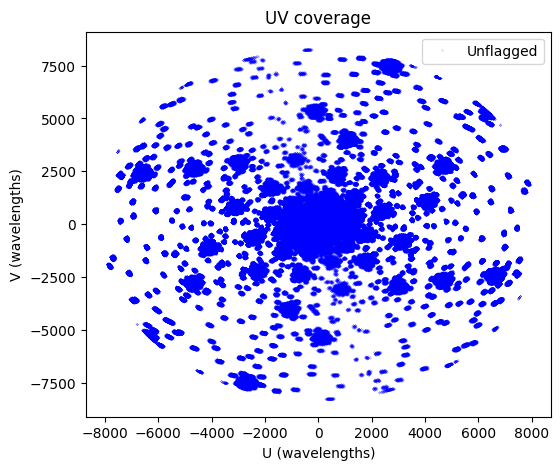

Model image plate scale (arcsec) is 1.951046e+00


There is no flagged visibility. Skip plotting flagged.


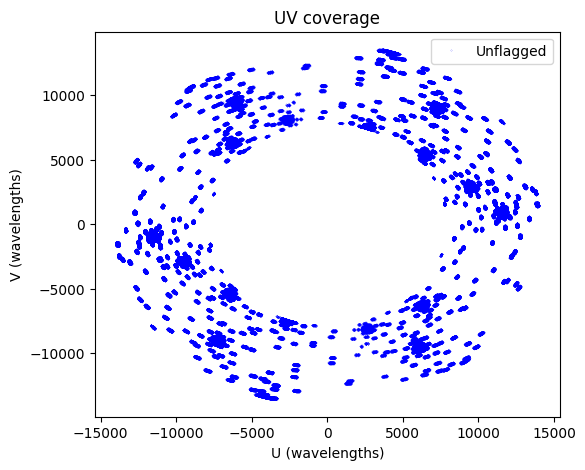

Model image plate scale (arcsec) is 1.951046e+00


There is no flagged visibility. Skip plotting flagged.


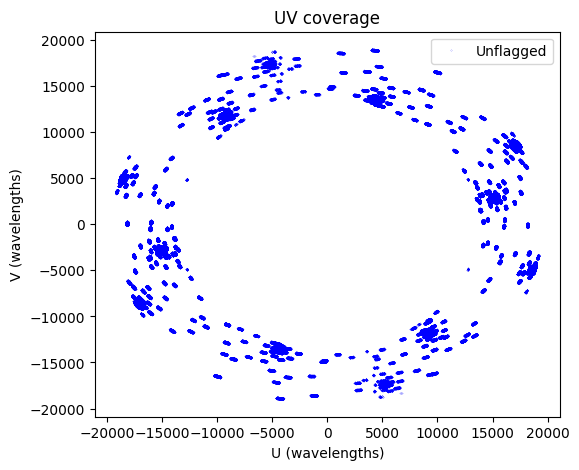

Model image plate scale (arcsec) is 1.951046e+00


There is no flagged visibility. Skip plotting flagged.


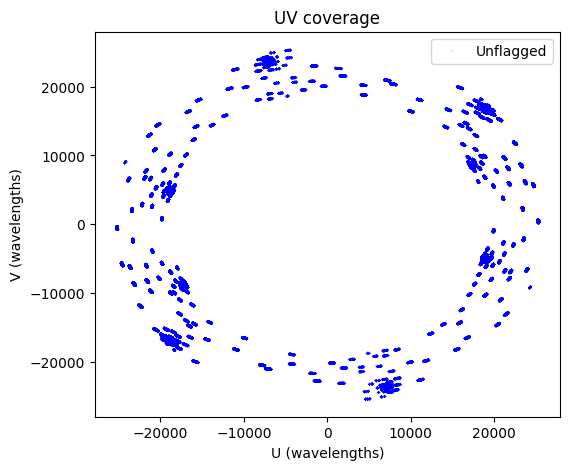

Model image plate scale (arcsec) is 1.951046e+00


There is no flagged visibility. Skip plotting flagged.


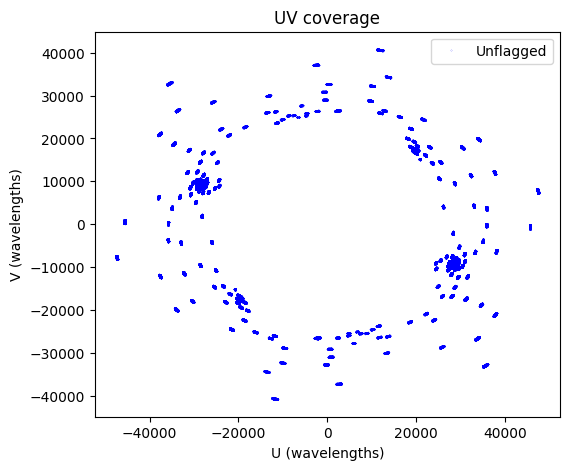

Model image plate scale (arcsec) is 1.951046e+00


In [9]:
matplotlib.rcParams['figure.figsize'] = [6, 5]

psfs = []
dirties = []
fdirties = []

for i, ell in enumerate(ells):
    gc.collect()
    curr_ms_file = output_name + str(i) + ".ms"
    [curr_vis], _ = ingest.create_visibility_from_ms(curr_ms_file, use_weight_spec=False, start_chan=0, end_chan=0, selected_dds=[0])
    
    if curr_vis.vis.size < 5e7:
        plot_uvcoverage([curr_vis])
    
    curr_dirty, curr_psf = residual.dirty_psf_from_visibilities(curr_vis,cell_size,npix=npix,weighting="uniform", override_cellsize=False)
    curr_fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(curr_dirty.pixels.data[0,0,:,:]))))
    
    psfs.append(curr_psf)
    dirties.append(curr_dirty)
    fdirties.append(curr_fdirty)

gc.collect()
    
curr_ms_file = output_name + str(len(ells)) + ".ms"
[curr_vis], _ = ingest.create_visibility_from_ms(curr_ms_file, use_weight_spec=False, start_chan=0, end_chan=0, selected_dds=[0])

if curr_vis.vis.size < 5e7:
    plot_uvcoverage([curr_vis])

curr_dirty, curr_psf = residual.dirty_psf_from_visibilities(curr_vis,cell_size,npix=npix,weighting="uniform", override_cellsize=False)
curr_fdirty = numpy.abs(numpy.fft.fftshift(numpy.fft.fft2(numpy.fft.ifftshift(curr_dirty.pixels.data[0,0,:,:]))))

psfs.append(curr_psf)
dirties.append(curr_dirty)
fdirties.append(curr_fdirty)

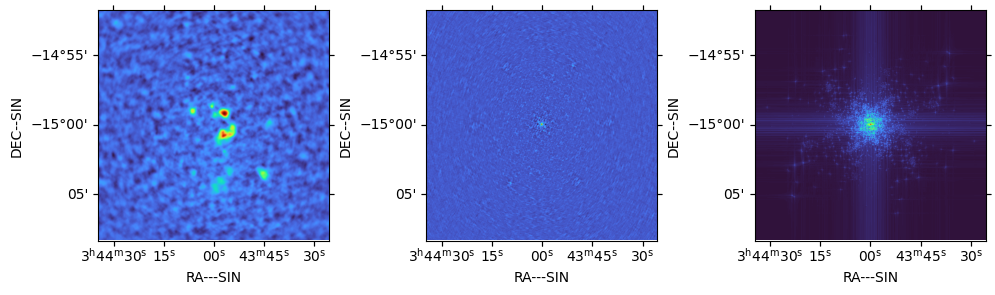

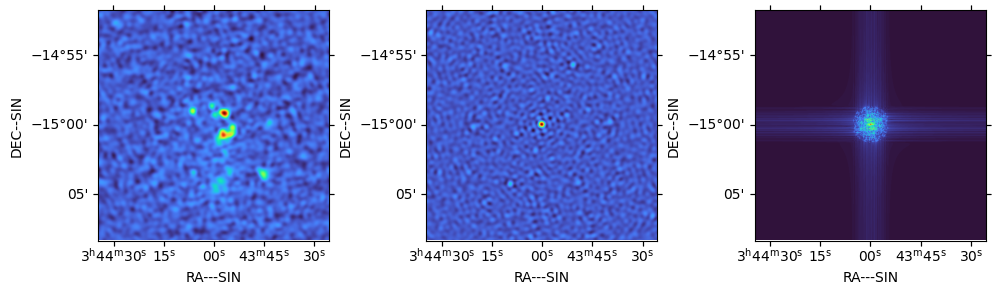

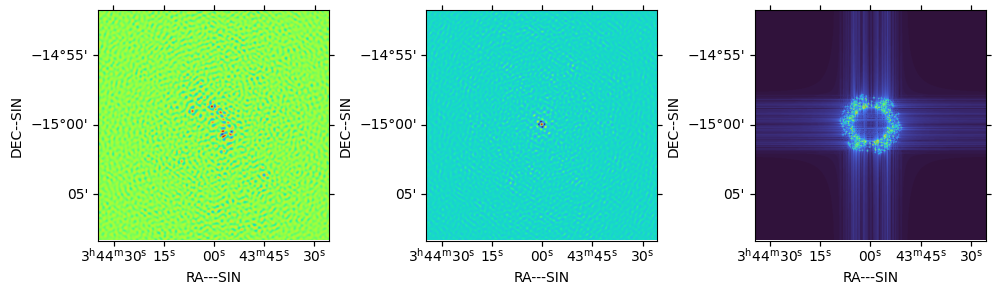

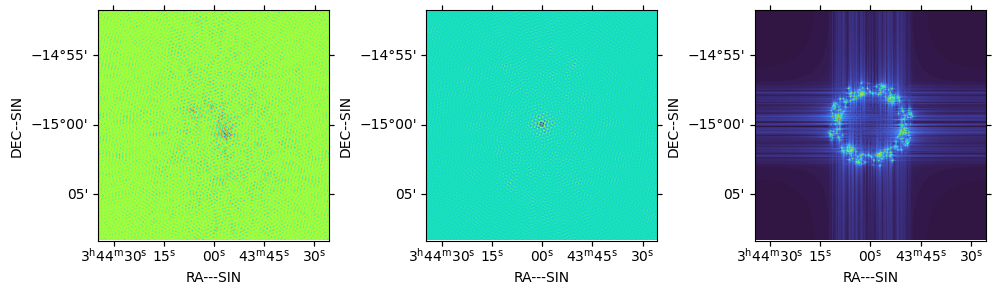

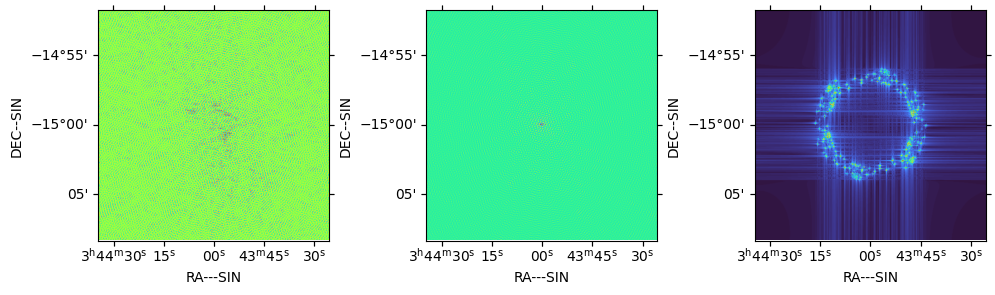

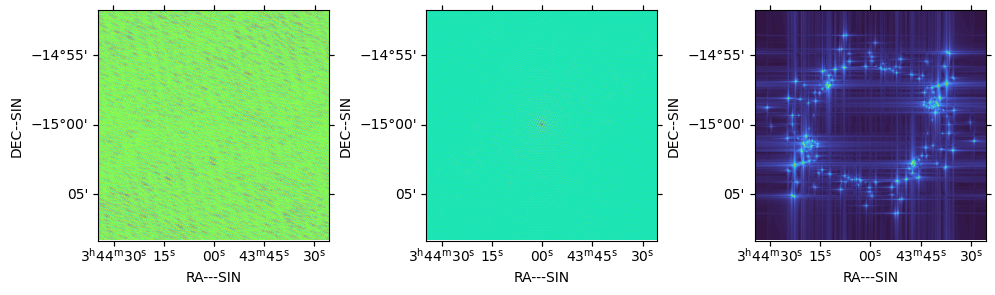

In [10]:
num_datasets = len(ells) + 1

fig = plt.figure(figsize=(12,3))
ax=fig.add_subplot(1,3,1,projection=dirty.image_acc.wcs.sub([1, 2]))
ax.imshow(dirty.pixels.data[0,0,:,:],origin='lower',cmap=cmap)
ax.set_xlabel(dirty.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(dirty.image_acc.wcs.wcs.ctype[1])

ax=fig.add_subplot(1,3,2,projection=psf.image_acc.wcs.sub([1, 2]))
ax.imshow(psf.pixels.data[0,0,:,:],origin='lower',cmap=cmap)
ax.set_xlabel(psf.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(psf.image_acc.wcs.wcs.ctype[1])

ax=fig.add_subplot(1,3,3,projection=dirty.image_acc.wcs.sub([1, 2]))
ax.imshow(numpy.sqrt(fdirty),origin='lower',cmap=cmap)
ax.set_xlabel(dirty.image_acc.wcs.wcs.ctype[0])
ax.set_ylabel(dirty.image_acc.wcs.wcs.ctype[1])

#display all partitions
for i, curr_dirty in enumerate(dirties):
    fig = plt.figure(figsize=(12,3))
    ax=fig.add_subplot(1,3,1,projection=dirties[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(dirties[i].pixels.data[0,0,:,:],origin='lower',cmap=cmap)
    ax.set_xlabel(dirties[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(dirties[i].image_acc.wcs.wcs.ctype[1])

    ax=fig.add_subplot(1,3,2,projection=psfs[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(psfs[i].pixels.data[0,0,:,:],origin='lower',cmap=cmap)
    ax.set_xlabel(psfs[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(psfs[i].image_acc.wcs.wcs.ctype[1])

    ax=fig.add_subplot(1,3,3,projection=dirties[i].image_acc.wcs.sub([1, 2]))
    ax.imshow(numpy.sqrt(fdirties[i]),origin='lower',cmap=cmap)
    ax.set_xlabel(dirties[i].image_acc.wcs.wcs.ctype[0])
    ax.set_ylabel(dirties[i].image_acc.wcs.wcs.ctype[1])

plt.savefig("../figures/partitionvis.png", pad_inches=0.0, bbox_inches='tight')


(-0.5, 1.1)

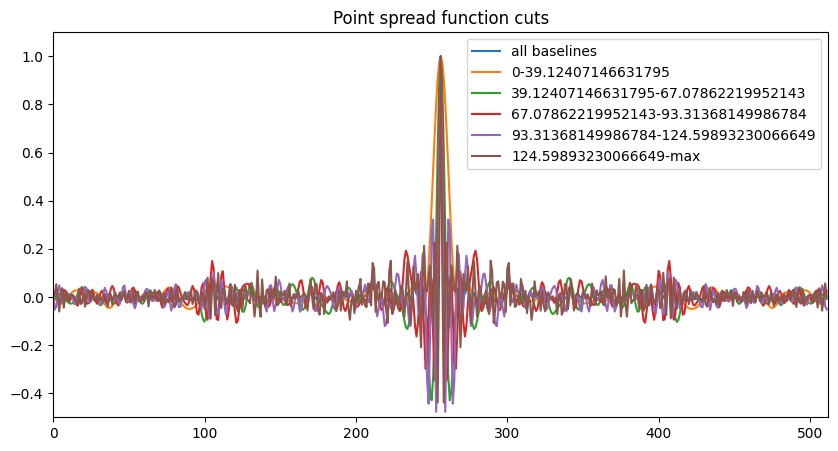

In [11]:
matplotlib.rcParams['figure.figsize'] = [10, 5]

size = 256

plt.plot(psf['pixels'].data[0,0,256,:],label='all baselines')
for i, curr_psf in enumerate(psfs):
    curr_range_low = 0 if i == 0 else ells[i - 1]
    curr_range_high = ells[i] if i < len(ells) else "max"
    range_label = str(curr_range_low) + "-" + str(curr_range_high)
    plt.plot(curr_psf['pixels'].data[0,0,256,:],label=range_label)
    
plt.legend()
plt.title('Point spread function cuts')
plt.xlim((256 - size, 256 + size)); plt.ylim((-0.5,1.1))

# 